# **Projeto de IA - Aprendizado de Máquina**

**Grupo:**

Gabriel Negreiro Oliveira

Marcello Ryaj de Almeida Santos

Mateus Levi Morais Feitosa

## **O conjunto de dados**

O conjunto de dados utilizado neste projeto é o mfeat-zernike, que faz parte do conjunto Multiple Features, disponibilizado pelo UCI Machine Learning Repository. Seu objetivo é classificar dígitos manuscritos em dez classes, correspondentes aos números de 0 a 9. 
 
Cada instância representa um dígito manuscrito, escrito à mão e extraído de uma coleção de mapas de serviços públicos holandeses. Cada imagem foi convertida em uma representação binária e, a partir dela, foram obtidos momentos de Zernike que descrevem características de sua forma.

In [1]:
!pip install seaborn

In [2]:
# Bibliotecas para trabalhar com tabelas e valores numéricos
import numpy as np
import pandas as pd

# Importa as ferramentas para padronização e PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Biblioteca para carregar o arquivo no formato ARFF
from scipy.io import arff

# Bibliotecas para geração de gráficos
import matplotlib.pyplot as plt

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


In [3]:
# Carrega os dados do arquivo ARFF
dados, metadados = arff.loadarff("dataset_22_mfeat-zernike.arff")

# Converte os dados para uma tabela
df = pd.DataFrame(dados)

# Converte os rótulos das classes para números inteiros
df["class"] = df["class"].str.decode("utf-8").astype(int)

# Mostra as cinco primeiras instâncias
df.head()

,att1,att2,att3,att4,att5,att6,att7,att8,att9,att10,...,att39,att40,att41,att42,att43,att44,att45,att46,att47,class
0,0.011033,0.831466,15.351804,75.806559,171.554214,490.156556,206.416027,0.122135,2.601646,11.472709,...,33.810340,9.858915,1.399891,148.138058,326.239452,9.711070,20.007248,47.032578,539.208457,1
1,0.038271,1.166746,10.526913,42.369276,85.187116,420.360566,253.569574,0.033657,0.390566,11.700830,...,35.400531,70.681899,6.674412,155.135985,377.832675,8.140633,44.536711,46.338954,518.496567,1
2,0.042698,1.225007,8.273804,31.744786,54.448177,404.103204,389.980746,0.041733,0.937399,11.629045,...,19.477230,30.093590,7.858211,150.126419,419.565747,4.530921,26.292170,44.574822,549.912691,1
3,0.032418,1.638247,19.205283,51.196682,57.181760,429.052011,256.174645,0.073624,1.973268,13.057108,...,14.179518,30.564085,7.097728,173.840759,441.350376,3.706023,13.432311,51.739930,574.887814,1
4,0.015866,0.611561,8.627839,37.325052,48.509025,459.909634,238.572767,0.046477,1.117292,10.012169,...,8.705403,30.242473,9.015714,167.021185,332.479997,1.806273,23.689300,50.407770,492.227513,1


In [4]:
# Verifica o número de instâncias e colunas
print("Dimensão do conjunto:", df.shape)

# Verifica a quantidade de exemplos em cada classe
print("\nQuantidade de instâncias por classe:")
print(df["class"].value_counts().sort_index())

# Verifica se existem valores ausentes
print("\nQuantidade de valores ausentes:", df.isnull().sum().sum())

# Verifica se existem linhas repetidas
print("Quantidade de instâncias duplicadas:", df.duplicated().sum())

Dimensão do conjunto: (2000, 48)

Quantidade de instâncias por classe:
class
1     200
2     200
3     200
4     200
5     200
6     200
7     200
8     200
9     200
10    200
Name: count, dtype: int64

Quantidade de valores ausentes: 0
Quantidade de instâncias duplicadas: 6


In [5]:
# Cria uma tabela com as principais características do conjunto
resumo = pd.DataFrame({
    "Característica": [
        "Nome do conjunto",
        "Número de instâncias",
        "Número de atributos",
        "Tipo dos atributos",
        "Número de classes",
        "Distribuição das classes",
        "Valores ausentes"
    ],
    "Valor": [
        "mfeat-zernike",
        "2.000",
        "47",
        "Numéricos contínuos",
        "10",
        "200 instâncias por classe",
        "Não há"
    ]
})



O conjunto possui 2.000 instâncias, 47 atributos numéricos e dez classes balanceadas, com 200 exemplos em cada classe. Não há valores ausentes. Os atributos apresentam escalas distintas, aspecto que será considerado no pré-processamento dos modelos. No arquivo, a coluna class aparece com valores entre 1 e 10; essa é apenas uma codificação dos rótulos das dez classes de dígitos.

## **Análise exploratória dos dados**

Nesta seção, são apresentadas estatísticas descritivas e visualizações dos atributos do conjunto, com o objetivo de identificar padrões, escalas, dispersões e relações entre as classes.

In [6]:
# Separa os 47 atributos da coluna de classe
X = df.drop(columns="class")

# Calcula estatísticas descritivas para cada atributo
estatisticas = X.describe().T

# Exibe a tabela
estatisticas

,count,mean,std,min,25%,50%,75%,max
att1,2000.0,0.078554,0.066552,0.001094,0.032160,0.057027,0.106162,0.496841
att2,2000.0,1.764332,1.159269,0.032385,0.928543,1.550141,2.360365,9.363772
att3,2000.0,21.708127,11.728827,0.364935,12.391974,20.868980,29.715504,72.443632
att4,2000.0,69.881897,38.348810,2.240865,40.587107,63.220758,94.255601,200.558005
att5,2000.0,109.519676,53.202068,3.822781,69.938353,106.643071,143.995104,284.648888
att6,2000.0,266.027267,124.192494,1.937737,166.395919,258.039088,360.421939,563.061573
att7,2000.0,147.578565,100.397369,0.045660,60.878624,132.145970,220.408564,463.128264
att8,2000.0,0.117313,0.086653,0.002745,0.053369,0.094367,0.162198,0.629253
att9,2000.0,2.612039,1.615522,0.073840,1.362552,2.361967,3.526661,13.115040
att10,2000.0,24.564107,17.233333,0.559946,11.906010,20.464571,32.672407,92.652118


In [7]:
# Resume os valores gerais encontrados entre todos os atributos
print("Menor valor do conjunto:", X.min().min())
print("Maior valor do conjunto:", X.max().max())
print("Menor desvio padrão:", X.std().min())
print("Maior desvio padrão:", X.std().max())

Menor valor do conjunto: 0.00109432
Maior valor do conjunto: 777.86182699
Menor desvio padrão: 0.06655200271465168
Maior desvio padrão: 124.19249364407261


As estatísticas descritivas mostram que os atributos possuem escalas e dispersões bastante distintas. Enquanto o menor valor observado no conjunto é aproximadamente 0,001, o maior chega a 777,862. Além disso, os desvios padrão variam de 0,067 a 124,192. Portanto, alguns atributos apresentam uma variação muito maior que outros, o que justifica a aplicação de padronização antes do treinamento de modelos sensíveis à escala dos dados.

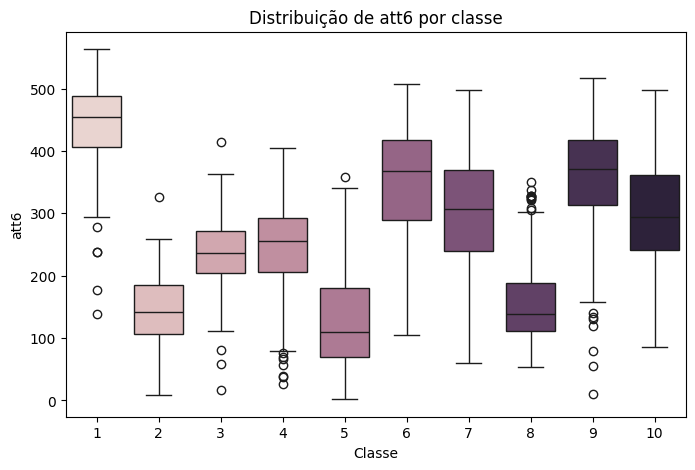

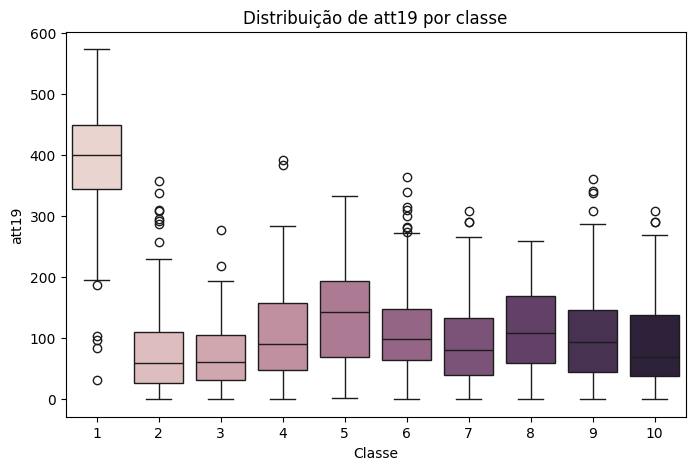

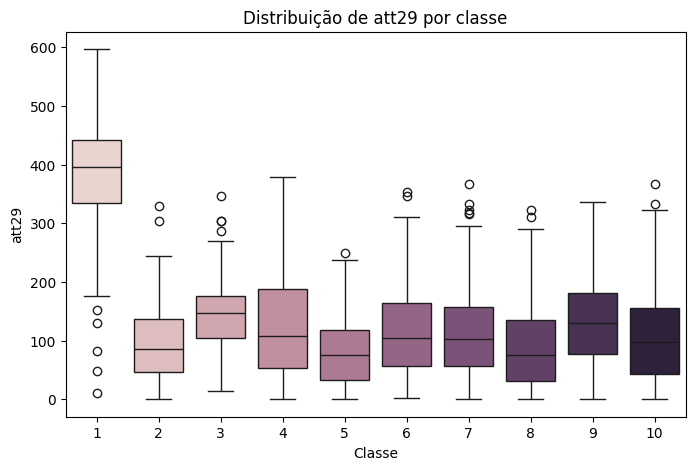

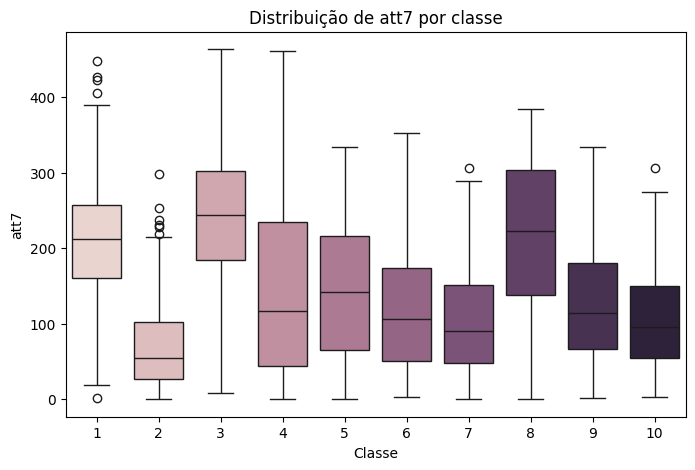

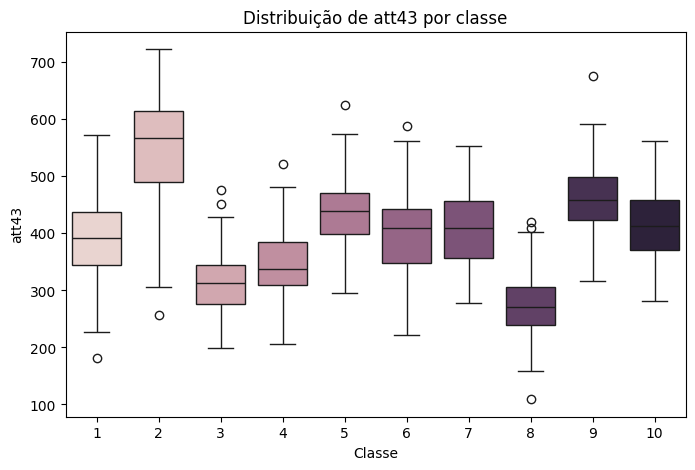

In [8]:
# Importa a biblioteca para os gráficos
import seaborn as sns

# Seleciona os cinco atributos com maior desvio padrão
atributos_selecionados = X.std().nlargest(5).index

# Cria um boxplot para cada atributo selecionado
for atributo in atributos_selecionados:
    plt.figure(figsize=(8, 5))
    
    sns.boxplot(
        x="class",
        y=atributo,
        data=df,
        hue="class",
        legend=False
    )
    
    plt.title(f"Distribuição de {atributo} por classe")
    plt.xlabel("Classe")
    plt.ylabel(atributo)
    plt.show()

Os boxplots dos cinco atributos selecionados mostram que as classes apresentam diferenças em suas medianas e dispersões. Nos atributos att6, att19 e att29, a classe 1 se destaca por apresentar valores centrais mais elevados que grande parte das demais classes. No atributo att43, a classe 2 possui mediana mais alta, enquanto a classe 8 concentra valores menores. Já em att7, algumas classes também apresentam faixas distintas, embora haja maior sobreposição entre as distribuições. Os pontos fora das hastes representam observações afastadas do padrão típico de suas classes. De modo geral, os gráficos indicam que os atributos contribuem para diferenciar alguns grupos de dígitos, mas as sobreposições mostram que a classificação depende da combinação dos 47 atributos.

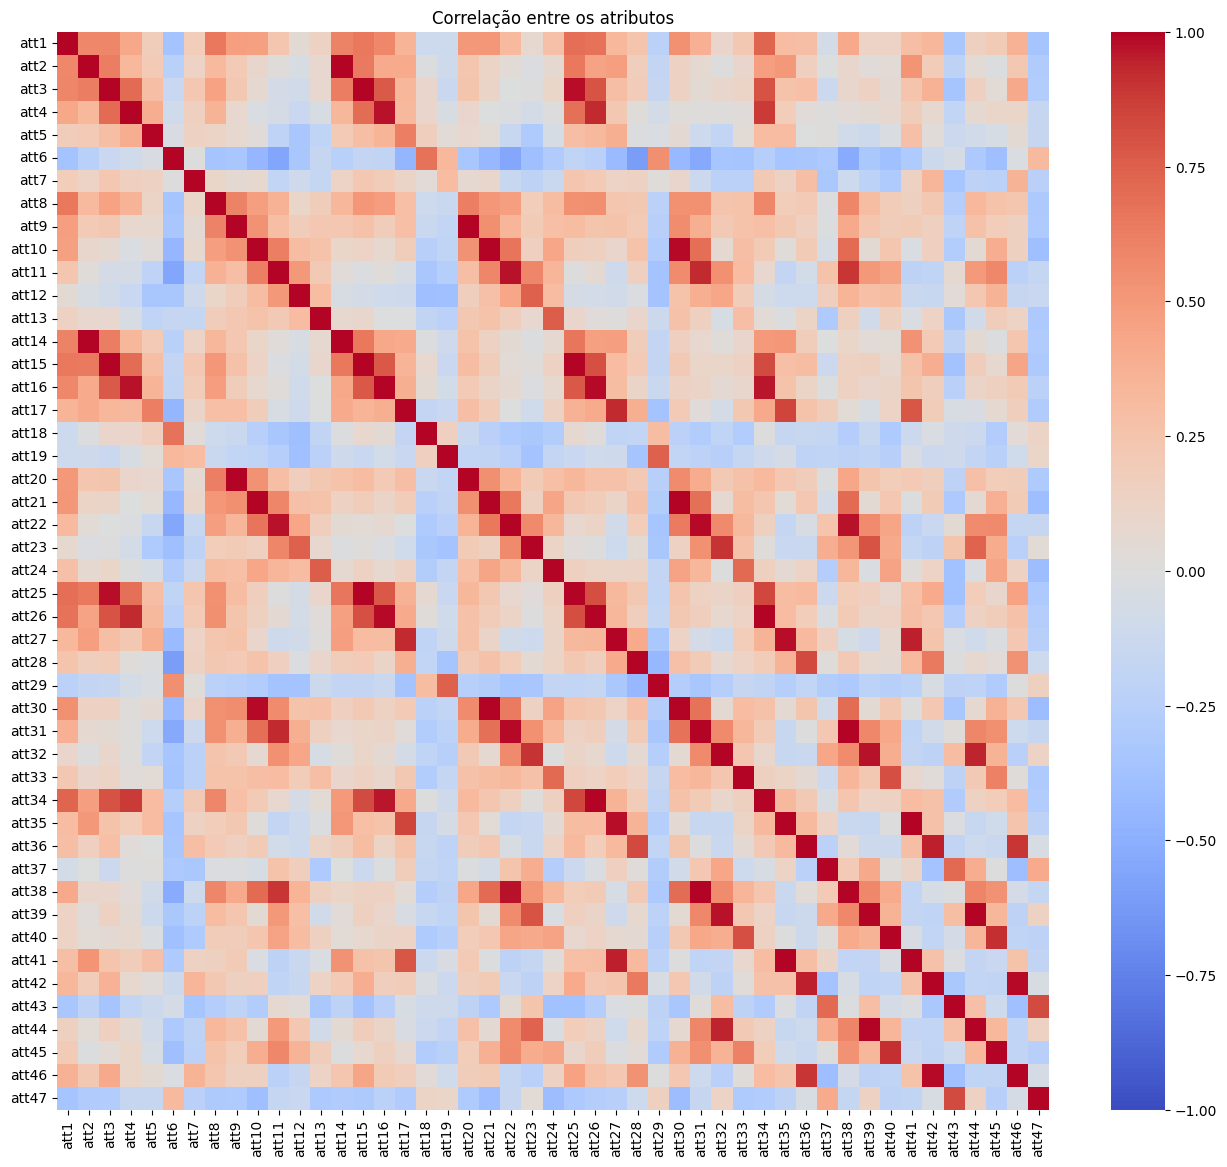

In [9]:
# Matriz de correlação entre os atributos
df_correlation = df[df.columns.drop("class")].corr()

# Cria o heatmap
plt.figure(figsize=(16, 14))

sns.heatmap(
    df_correlation,
    xticklabels=df_correlation.columns,
    yticklabels=df_correlation.columns,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Correlação entre os atributos")
plt.show()

A diagonal principal apresenta correlação igual a 1, pois cada atributo é perfeitamente correlacionado com ele mesmo. Fora da diagonal, observam-se blocos em tons de vermelho, indicando grupos de atributos com correlação positiva moderada ou forte. Também há regiões em azul, que representam relações negativas entre alguns atributos. Entretanto, grande parte da matriz apresenta cores claras, indicando correlações fracas ou moderadas. Esses padrões mostram que os momentos de Zernike não são totalmente independentes e que alguns atributos carregam informações semelhantes sobre a forma dos dígitos. A existência de atributos correlacionados será considerada na etapa de treinamento dos modelos.

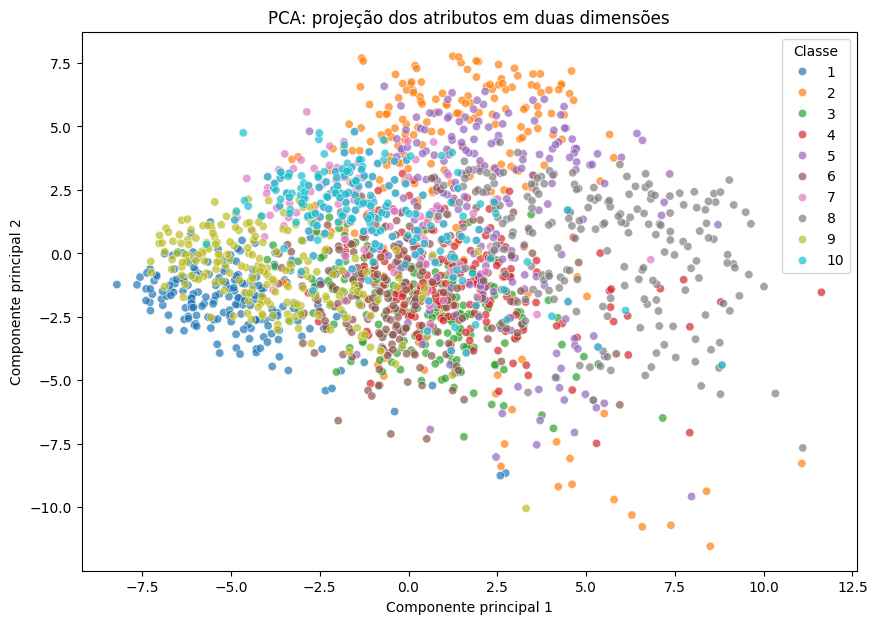

In [10]:
# Padroniza os atributos somente para a visualização por PCA
X_padronizado = StandardScaler().fit_transform(X)

# Reduz os 47 atributos para duas componentes principais
pca = PCA(n_components=2)
componentes_principais = pca.fit_transform(X_padronizado)

# Cria uma nova tabela para o gráfico
df_pca = pd.DataFrame(
    componentes_principais,
    columns=["Componente 1", "Componente 2"]
)

# Adiciona a classe como texto para usar cores distintas
df_pca["class"] = df["class"].astype(str)

# Cria o scatter plot
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_pca,
    x="Componente 1",
    y="Componente 2",
    hue="class",
    palette="tab10",
    alpha=0.7
)

plt.title("PCA: projeção dos atributos em duas dimensões")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend(title="Classe")
plt.show()

A projeção por PCA reduziu os 47 atributos a duas componentes principais para permitir a visualização dos dados. O gráfico mostra que algumas classes apresentam regiões parcialmente distintas, como a classe 8, que se concentra mais à direita, a classe 1, localizada majoritariamente à esquerda, e a classe 2, que tende a ocupar regiões superiores. Entretanto, várias classes se concentram na região central e apresentam sobreposição considerável, indicando que a separação entre todos os dígitos não é completa em apenas duas dimensões. Assim, os resultados sugerem que os atributos de Zernike contêm informação para diferenciar parte das classes, mas os modelos devem utilizar a combinação dos 47 atributos para realizar uma classificação mais precisa.

In [11]:
# Calcula a porcentagem da variabilidade explicada pelas duas componentes
variancia_explicada = pca.explained_variance_ratio_ * 100

print(f"Componente principal 1: {variancia_explicada[0]:.2f}%")
print(f"Componente principal 2: {variancia_explicada[1]:.2f}%")
print(f"Total explicado pelas duas componentes: {variancia_explicada.sum():.2f}%")

Componente principal 1: 26.02%
Componente principal 2: 18.61%
Total explicado pelas duas componentes: 44.63%


As duas componentes principais explicam, juntas, aproximadamente 44.63% da variabilidade total dos atributos.

## **Pré-processamentos**

Nesta seção são discutidos os pré-processamentos necessários ao mfeat-zernike. A discussão segue os grupos de tarefas de pré-processamento vistos na disciplina: integração de dados, eliminação manual de atributos, amostragem, redução de dimensionalidade, balanceamento, limpeza e transformação de dados. Para cada grupo verifica-se se ele se aplica ao conjunto escolhido.

In [12]:
# Verifica as condições que determinam quais pré-processamentos são necessários

# Quantidade de valores ausentes no conjunto
print("Valores ausentes:", df.isnull().sum().sum())

# Quantidade de instâncias repetidas
print("Instâncias duplicadas:", df.duplicated().sum())

# Tipos dos atributos preditivos
print("Tipos dos atributos:", X.dtypes.unique())

# Distribuição das classes
print("Menor classe:", df["class"].value_counts().min(), "instâncias")
print("Maior classe:", df["class"].value_counts().max(), "instâncias")

Valores ausentes: 0
Instâncias duplicadas: 6
Tipos dos atributos: [dtype('float64')]
Menor classe: 200 instâncias
Maior classe: 200 instâncias


Assim, a verificação confirma alguns processamentos dispensáveis para o nosso caso:

- Integração de dados: Todo o conjunto provém de um único arquivo;
- Amostragem de dados: As 2000 instâncias são processadas normalmente, não há custo computacional que justifique trabalhar com amostras;
- Balanceamento de dados: As dez classes possuem exatamente 200 instâncias cada;
- Eliminação manual de atributos: Os 47 atributos são momentos de Zernike de mesma natureza;
- Dados incompletos: Não há valores ausentes;
- Conversão de tipos: Os atributos preditivos são quantitativos contínuos. A única conversão realizada foi a do rótulo, decodificado de texto para inteiro durante o carregamento do arquivo.

A limpeza de dados trata de ruídos, inconsistências, redundâncias e dados incompletos. O último caso já foi descartado. Resta verificar redundâncias entre instâncias e discutir o tratamento de ruídos e outliers.

In [13]:
# Seleciona todas as linhas envolvidas em alguma duplicação
duplicadas = df[df.duplicated(keep=False)]

print("Linhas envolvidas em duplicação:", duplicadas.shape[0])
print("Classes dessas linhas:", sorted(duplicadas["class"].unique().tolist()))

# Cria uma chave que identifica instâncias com os mesmos 47 atributos
chave = X.round(6).astype(str).agg("|".join, axis=1)

# Conta quantas classes diferentes aparecem em cada grupo de atributos idênticos
grupos = df.groupby(chave)["class"].nunique()

print("\nGrupos de instâncias com atributos idênticos:", (df.groupby(chave).size() > 1).sum())
print("Grupos com classes conflitantes:", (grupos > 1).sum())

Linhas envolvidas em duplicação: 12
Classes dessas linhas: [4, 6, 7, 8, 10]

Grupos de instâncias com atributos idênticos: 6
Grupos com classes conflitantes: 0


Os seis pares de instâncias duplicadas envolvem doze linhas, e nenhum grupo apresenta classes conflitantes: em todos os casos as instâncias repetidas pertencem à mesma classe. Trata-se, portanto, de redundância, e não de inconsistência. A decisão adotada foi remover as duplicatas, preservando apenas a primeira ocorrência de cada instância repetida. A razão é metodológica. Se as duas cópias de um par caírem em dobras diferentes da validação cruzada, a instância avaliada terá sua cópia exata no conjunto de treinamento, e o modelo acertará por memorização, não por generalização. Isso produz uma estimativa otimista de desempenho.

In [14]:
# Remove as instâncias duplicadas, mantendo a primeira ocorrência de cada uma
df = df.drop_duplicates().reset_index(drop=True)

# Atualiza a tabela de atributos após a remoção
X = df.drop(columns="class")

print("Instâncias após a remoção:", df.shape[0])
print("Duplicatas restantes:", df.duplicated().sum())

print("\nQuantidade de instâncias por classe:")
print(df["class"].value_counts().sort_index())

Instâncias após a remoção: 1994
Duplicatas restantes: 0

Quantidade de instâncias por classe:
class
1     200
2     200
3     200
4     199
5     200
6     199
7     198
8     199
9     200
10    199
Name: count, dtype: int64


O conjunto passou de 2.000 para 1.994 exemplos. A distribuição das classes permanece praticamente uniforme, entre 198 e 200 instâncias por classe, de modo que a conclusão anterior sobre o balanceamento continua válida e nenhuma técnica de balanceamento se torna necessária.

Ruídos e outliers: Os boxplots da seção anterior mostraram diversos pontos além das hastes. Nenhum procedimento de remoção foi aplicado a eles. Os momentos de Zernike descrevem a forma do dígito, e um valor extremo tende a corresponder a uma caligrafia atípica, porém legítima. A eliminação de ruídos pode levar à perda de informação importante, fazendo com que regiões inteiras do espaço de atributos deixem de ser representadas. Além disso, essas instâncias são justamente o objeto da última seção: exemplos próximos à fronteira de separação entre classes, potencialmente borderline, são o que a análise de erros pretende investigar. 

Algumas técnicas de Aprendizado de Máquina têm o desempenho influenciado pela variação dos valores numéricos, e o conjunto apresenta atributos em escalas bastante distintas. A célula a seguir quantifica essa diferença.

In [15]:
# Organiza as medidas de escala de cada atributo
escalas = pd.DataFrame({
    "Média": X.mean(),
    "Desvio padrão": X.std(),
    "Mínimo": X.min(),
    "Máximo": X.max()
})

# Mostra os cinco atributos de maior e de menor dispersão
print("Atributos com maior desvio padrão:")
print(escalas.nlargest(5, "Desvio padrão").round(3))

print("\nAtributos com menor desvio padrão:")
print(escalas.nsmallest(5, "Desvio padrão").round(3))

# Compara a ordem de grandeza entre o atributo mais e o menos disperso
print("\nRazão entre o maior e o menor desvio padrão: {:.1f}".format(X.std().max() / X.std().min()))

Atributos com maior desvio padrão:
         Média  Desvio padrão   Mínimo   Máximo
att6   266.066        124.246    1.938  563.062
att19  130.622        116.197    0.089  573.567
att29  139.631        111.588    0.065  596.668
att7   147.708        100.358    0.046  463.128
att43  399.306         96.385  109.141  722.998

Atributos com menor desvio padrão:
       Média  Desvio padrão  Mínimo  Máximo
att1   0.079          0.067   0.001   0.497
att8   0.117          0.087   0.003   0.629
att14  0.214          0.146   0.006   1.224
att20  0.342          0.219   0.007   1.858
att25  0.913          0.528   0.011   3.379

Razão entre o maior e o menor desvio padrão: 1866.2


A normalização é, portanto, necessária.

Adotou-se a padronização, que transforma cada atributo para média zero e desvio padrão unitário. A razão está no comportamento diante de outliers, isto é, na reescala min-max os valores mínimo e máximo definem os limites do novo intervalo, de modo que um único valor extremo comprime todos os demais em uma faixa estreita.

In [16]:
# Aplica a padronização a todos os atributos
scaler = StandardScaler()
X_padronizado = scaler.fit_transform(X)

# Converte o resultado para tabela
X_padronizado = pd.DataFrame(X_padronizado, columns=X.columns)

# Compara as escalas antes e depois da padronização
comparacao = pd.DataFrame({
    "Média antes": X.mean(),
    "Desvio antes": X.std(),
    "Média depois": X_padronizado.mean(),
    "Desvio depois": X_padronizado.std()
})

print(comparacao.loc[["att1", "att6", "att19", "att29", "att43"]].round(3))

       Média antes  Desvio antes  Média depois  Desvio depois
att1         0.079         0.067           0.0            1.0
att6       266.066       124.246          -0.0            1.0
att19      130.622       116.197           0.0            1.0
att29      139.631       111.588          -0.0            1.0
att43      399.306        96.385          -0.0            1.0


A redução de dimensionalidade pode ser obtida por agregação, como na PCA, que combina os atributos originais e elimina redundâncias por correlação, ou por seleção de atributos, que preserva um subconjunto dos atributos originais. O heatmap da seção anterior sugeriu a existência de grupos de atributos correlacionados, o que torna a questão pertinente. 

In [17]:
# Calcula a correlação absoluta entre todos os pares de atributos
correlacoes = X.corr().abs()

# Mantém apenas a parte superior da matriz para não contar o mesmo par duas vezes
triangulo = np.triu(np.ones(correlacoes.shape), k=1).astype(bool)
pares = correlacoes.where(triangulo).stack().dropna()

# Conta quantos pares ultrapassam diferentes limiares de correlação
print("Total de pares de atributos:", pares.shape[0])

for limiar in [0.5, 0.8, 0.9]:
    quantidade = (pares > limiar).sum()
    print("Pares com correlação acima de {}: {} ({:.1f}%)".format(limiar, quantidade, 100 * quantidade / pares.shape[0]))

print("\nCorrelação mediana entre os pares: {:.3f}".format(pares.median()))
print("Maior correlação observada: {:.3f}".format(pares.max()), "entre", pares.idxmax())

Total de pares de atributos: 1081
Pares com correlação acima de 0.5: 137 (12.7%)
Pares com correlação acima de 0.8: 40 (3.7%)
Pares com correlação acima de 0.9: 29 (2.7%)

Correlação mediana entre os pares: 0.205
Maior correlação observada: 0.998 entre ('att2', 'att14')


In [65]:
# Verifica quantas componentes principais preservariam a variabilidade dos 47 atributos
X_para_pca = StandardScaler().fit_transform(X)

pca_completa = PCA()
pca_completa.fit(X_para_pca)

# Acumula a variabilidade explicada componente a componente
variancia_acumulada = np.cumsum(pca_completa.explained_variance_ratio_)

for alvo in [0.90, 0.95, 0.99]:
    componentes = np.searchsorted(variancia_acumulada, alvo) + 1
    print("Componentes necessárias para {:.0f}% da variabilidade: {} de 47".format(alvo * 100, componentes))

Componentes necessárias para 90% da variabilidade: 12 de 47
Componentes necessárias para 95% da variabilidade: 16 de 47
Componentes necessárias para 99% da variabilidade: 22 de 47


Os atributos são pouco correlacionados entre si. A correlação mediana entre os pares é 0.205, e só 29 dos 1081 pares passam de 0.9. O par att2 e att14 chega a 0.998, mas é caso isolado. Mesmo assim, dá para resumir os 47 atributos em 16 sem perder quase nada: 16 componentes principais guardam 95% da variabilidade, e 12 já guardam 90%. Existe redundância, só não na forma de atributos repetidos, e sim espalhada por muitas correlações fracas que se somam.

Então, se há redundância, vale apena removê-la? Neste problema, não:
O conjunto não tem atributos demais. São 1994 exemplos para 47 atributos, cerca de 42 por dimensão. Reduzir dimensões serve para o caso oposto.
A PCA olha para a variação, não para as classes. Espalhar não é separar, e os 5% descartados podem ser justamente o que distingue os dígitos difíceis.
Com PCA, não dá para explicar os erros. Cada componente é uma mistura dos 47 atributos, e apontar qual característica da forma causou o erro é o objetivo do trabalho. Ademais, os modelos já dão conta da redundância. A penalização L2 divide o peso entre atributos parecidos, e a Random Forest sorteia atributos a cada divisão, por exemplo.

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

# Encadeia a padronização e o modelo em um único objeto
pipeline_exemplo = Pipeline([
    ("padronizacao", StandardScaler()),
    ("modelo", KNeighborsClassifier(n_neighbors=3))
])

print(pipeline_exemplo)

Pipeline(steps=[('padronizacao', StandardScaler()),
                ('modelo', KNeighborsClassifier(n_neighbors=3))])


Logo, a cada dobra da validação cruzada, fit é chamado sobre os dados de treinamento, ajustando a média e o desvio padrão e treinando o modelo em seguida, enquanto predict aplica ao conjunto de validação a transformação aprendida no treinamento. Evitando vazamento de dados.

## **Aplicando o pipeline de AM**

Nesta seção o conjunto de dados passa por um pipeline completo de Aprendizado de Máquina. Os dados cumprem três papéis: treinar o modelo, escolher os hiperparâmetros e estimar o desempenho final.

Para manter esses papéis separados, usamos validação cruzada aninhada. O laço externo divide os dados em 10 dobras e serve apenas para medir desempenho. Dentro de cada uma delas, um laço interno de 3 dobras escolhe os hiperparâmetros usando apenas os dados de treinamento daquela dobra. Assim, a partição de teste não influencia nem a escolha dos hiperparâmetros nem a padronização.

Como referência, foi utilizado um `DummyClassifier` com a estratégia `most_frequent`. Esse classificador ignora os 47 atributos e sempre prevê a classe mais frequente, estabelecendo um desempenho mínimo para comparação com os modelos treinados posteriormente.

In [19]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

# Define a validação cruzada estratificada externa com 10 dobras
cv_externa = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Cria o classificador de referência
dummy = DummyClassifier(strategy="most_frequent")

# Avalia o baseline com as mesmas métricas que serão usadas nos outros modelos
resultados_dummy = cross_validate(
    dummy,
    X,
    df["class"],
    cv=cv_externa,
    scoring={"accuracy": "accuracy", "f1_macro": "f1_macro"}
)

# Organiza a média e o desvio padrão das métricas
tabela_dummy = pd.DataFrame({
    "Métrica": ["Acurácia", "F1 macro"],
    "Média": [
        resultados_dummy["test_accuracy"].mean(),
        resultados_dummy["test_f1_macro"].mean()
    ],
    "Desvio padrão": [
        resultados_dummy["test_accuracy"].std(),
        resultados_dummy["test_f1_macro"].std()
    ]
})

tabela_dummy.round(3)

,Métrica,Média,Desvio padrão
0,Acurácia,0.100,0.0
1,F1 macro,0.018,0.0


O `DummyClassifier` obteve acurácia de 0,100 e F1 macro de 0,018, com variação praticamente nula entre as dobras. Como o conjunto possui dez classes de tamanho quase idêntico, o modelo acerta apenas a fração correspondente à classe que prevê sempre. Esse é o piso de desempenho: qualquer modelo que aprenda algo dos 47 atributos deve superá-lo com folga.

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from scipy.stats import wilcoxon

import time

# Semente aleatória para reprodutibilidade dos experimentos
seed = 42

# Validação cruzada interna, usada para escolher hiperparâmetros dentro de cada dobra externa
cv_interna = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)

# Métricas calculadas em cada dobra externa
metricas = {
    "acuracia": "accuracy",
    "f1_macro": "f1_macro",
    "auc": "roc_auc_ovr"
}

# Separa os rótulos, já sem as instâncias duplicadas
y = df["class"]

print("Conjunto avaliado:", X.shape[0], "instâncias e", X.shape[1], "atributos")

Conjunto avaliado: 1994 instâncias e 47 atributos


Quatro técnicas são comparadas: a regressão logística, que traça fronteiras retas; o k-NN, que decide pela proximidade entre exemplos; o SVM com kernel RBF, que traça fronteiras curvas; e a Random Forest, que combina árvores de decisão.

Os hiperparâmetros de cada uma controlam, no fundo, a mesma coisa: o quanto o modelo pode se moldar aos dados de treinamento. Na regressão logística e no SVM, o C regula a tolerância a erros durante o treino. No SVM, o gamma define o alcance da influência de cada exemplo. No k-NN, o número de vizinhos decide se a classificação olha só para a vizinhança imediata ou para uma região ampla. Na Random Forest, o número de atributos sorteados por divisão e o tamanho mínimo das folhas limitam o crescimento das árvores. Os valores testados estão na célula abaixo. O número de árvores da Random Forest foi fixado em 300.

Cada entrada do dicionário é um GridSearchCV envolvendo um Pipeline, e é essa construção que impede o vazamento: quando o laço externo avalia o GridSearchCV, a padronização e a busca de hiperparâmetros são refeitas dentro de cada dobra, usando só os dados de treinamento dela.

In [21]:
algoritmos = {
    "Regressão logística": GridSearchCV(
        Pipeline([
            ("padronizacao", StandardScaler()),
            ("modelo", LogisticRegression(max_iter=5000, random_state=seed))]),
        param_grid={
            "modelo__C": [0.01, 0.1, 1, 10, 100],
        },
        scoring="accuracy",
        cv=cv_interna),

    "k-NN": GridSearchCV(
        Pipeline([
            ("padronizacao", StandardScaler()),
            ("modelo", KNeighborsClassifier())]),
        param_grid={
            "modelo__n_neighbors": [1, 3, 5, 7, 9, 11],
            "modelo__weights": ["uniform", "distance"],
        },
        scoring="accuracy",
        cv=cv_interna),

    "SVM RBF": GridSearchCV(
        Pipeline([
            ("padronizacao", StandardScaler()),
            ("modelo", SVC(kernel="rbf", probability=True, random_state=seed))]),
        param_grid={
            "modelo__C": [0.1, 1, 10, 100],
            "modelo__gamma": ["scale", 0.001, 0.01, 0.1],
        },
        scoring="accuracy",
        cv=cv_interna),

    "Random Forest": GridSearchCV(
        Pipeline([
            ("padronizacao", StandardScaler()),
            ("modelo", RandomForestClassifier(n_estimators=300, random_state=seed))]),
        param_grid={
            "modelo__max_features": ["sqrt", "log2", 0.3],
            "modelo__min_samples_leaf": [1, 3],
        },
        scoring="accuracy",
        cv=cv_interna),
}

A célula seguinte executa a avaliação. Cada modelo passa pelas dez dobras externas e, em cada uma delas, por uma busca completa de hiperparâmetros com validação interna de três dobras.

In [22]:
resultados = {}

for nome, algoritmo in algoritmos.items():
    inicio = time.time()

    resultados[nome] = cross_validate(
        algoritmo,
        X,
        y,
        cv=cv_externa,
        scoring=metricas,
        return_estimator=True,
        n_jobs=-1
    )

    print("{:<22} avaliado em {:.0f} s".format(nome, time.time() - inicio))

Regressão logística    avaliado em 7 s
k-NN                   avaliado em 4 s
SVM RBF                avaliado em 32 s
Random Forest          avaliado em 53 s


In [23]:
# Organiza o desempenho de cada modelo em cada uma das dez dobras externas
desempenho = {}

for chave in metricas:
    desempenho[chave] = pd.DataFrame({nome: r["test_" + chave] for nome, r in resultados.items()})

# Acurácia obtida por cada modelo em cada dobra
print("Acurácia por dobra externa:")
print(desempenho["acuracia"].round(4))

Acurácia por dobra externa:
   Regressão logística    k-NN  SVM RBF  Random Forest
0               0.8500  0.7700   0.8350         0.7650
1               0.8050  0.8100   0.8000         0.7600
2               0.8500  0.8300   0.8700         0.7750
3               0.7900  0.8100   0.8000         0.7700
4               0.8191  0.7839   0.8241         0.7739
5               0.7889  0.8090   0.8040         0.7538
6               0.7990  0.8090   0.8291         0.7638
7               0.8492  0.8291   0.8693         0.7839
8               0.8241  0.7789   0.8392         0.7889
9               0.8241  0.7990   0.8342         0.7839


In [24]:
# Resume cada métrica pela média e pelo desvio padrão das dez dobras
resumo = pd.DataFrame({
    chave: tabela.apply(lambda x: "{:.3f} ± {:.3f}".format(x.mean(), x.std()))
    for chave, tabela in desempenho.items()
})

resumo

,acuracia,f1_macro,auc
Regressão logística,0.820 ± 0.024,0.815 ± 0.025,0.981 ± 0.003
k-NN,0.803 ± 0.020,0.799 ± 0.020,0.967 ± 0.007
SVM RBF,0.831 ± 0.025,0.826 ± 0.026,0.989 ± 0.002
Random Forest,0.772 ± 0.011,0.767 ± 0.010,0.968 ± 0.004


Os quatro modelos superam com larga margem o baseline de 0,100, confirmando que os momentos de Zernike carregam informação suficiente para distinguir os dígitos.

Os desvios ficam entre 0,010 e 0,026, ou seja, entre um e três pontos percentuais. A Random Forest é o modelo mais estável, com desvio de 0,011, e ao mesmo tempo o pior: consistência não é qualidade quando o modelo é consistentemente inferior. Os demais oscilam cerca de 2,5 pontos entre dobras, variação compatível com o tamanho das partições de teste, que contêm por volta de 200 instâncias cada.Além disso, cada dobra externa executa sua própria busca, é possível verificar se as dez dobras convergem para configurações semelhantes

In [25]:
# Recupera o hiperparâmetro escolhido pela validação interna em cada dobra externa
for nome, resultado in resultados.items():
    escolhas = [str(estimador.best_params_) for estimador in resultado["estimator"]]
    contagem = pd.Series(escolhas).value_counts()

    print(nome)
    for parametros, vezes in contagem.items():
        print("   {} de 10 dobras: {}".format(vezes, parametros))
    print()

Regressão logística
   8 de 10 dobras: {'modelo__C': 1}
   2 de 10 dobras: {'modelo__C': 10}

k-NN
   5 de 10 dobras: {'modelo__n_neighbors': 5, 'modelo__weights': 'uniform'}
   2 de 10 dobras: {'modelo__n_neighbors': 11, 'modelo__weights': 'uniform'}
   1 de 10 dobras: {'modelo__n_neighbors': 3, 'modelo__weights': 'uniform'}
   1 de 10 dobras: {'modelo__n_neighbors': 9, 'modelo__weights': 'uniform'}
   1 de 10 dobras: {'modelo__n_neighbors': 7, 'modelo__weights': 'uniform'}

SVM RBF
   4 de 10 dobras: {'modelo__C': 1, 'modelo__gamma': 'scale'}
   2 de 10 dobras: {'modelo__C': 10, 'modelo__gamma': 0.01}
   2 de 10 dobras: {'modelo__C': 100, 'modelo__gamma': 0.001}
   2 de 10 dobras: {'modelo__C': 1, 'modelo__gamma': 0.01}

Random Forest
   5 de 10 dobras: {'modelo__max_features': 'sqrt', 'modelo__min_samples_leaf': 1}
   3 de 10 dobras: {'modelo__max_features': 'log2', 'modelo__min_samples_leaf': 1}
   2 de 10 dobras: {'modelo__max_features': 0.3, 'modelo__min_samples_leaf': 1}



Diferenças entre médias podem não ser estatisticamente significativas. O teste aplicado é o de Wilcoxon para amostras pareadas.

In [26]:
# Ordena os modelos pela acurácia média
ordem = desempenho["acuracia"].mean().sort_values(ascending=False)
melhor = ordem.index[0]

print("Modelo com maior acurácia média:", melhor)
print()

# Compara o melhor modelo com cada um dos demais sobre as mesmas dobras
for outro in ordem.index[1:]:
    diferenca = desempenho["acuracia"][melhor] - desempenho["acuracia"][outro]
    estatistica, p_valor = wilcoxon(desempenho["acuracia"][melhor], desempenho["acuracia"][outro])

    print("{} contra {}".format(melhor, outro))
    print("   diferença média de acurácia: {:+.4f}".format(diferenca.mean()))
    print("   dobras favoráveis ao {}: {} de 10".format(melhor, (diferenca > 0).sum()))
    print("   p-valor de Wilcoxon: {:.4f}".format(p_valor))
    print()

Modelo com maior acurácia média: SVM RBF

SVM RBF contra Regressão logística
   diferença média de acurácia: +0.0105
   dobras favoráveis ao SVM RBF: 8 de 10
   p-valor de Wilcoxon: 0.0273

SVM RBF contra k-NN
   diferença média de acurácia: +0.0276
   dobras favoráveis ao SVM RBF: 7 de 10
   p-valor de Wilcoxon: 0.0254

SVM RBF contra Random Forest
   diferença média de acurácia: +0.0587
   dobras favoráveis ao SVM RBF: 10 de 10
   p-valor de Wilcoxon: 0.0020



O SVM venceu a regressão logística em 8 das 10 dobras, o k-NN em 7 e a Random Forest em todas as 10. Os p-valores foram 0,027, 0,025 e 0,002, todos abaixo de 0,05.

A próxima célula investiga onde e por que os modelos erram, e para isso precisa de uma previsão para cada uma das 1994 instâncias. Reaproveitando os modelos ajustados em cada dobra, obtém-se uma previsão fora da dobra para todo o conjunto, sem nenhum treinamento adicional. Junto com a previsão, registra-se a probabilidade atribuída pelo modelo, cuja maior componente serve como medida de confiança.

In [27]:
# Reaproveita os modelos ajustados em cada dobra para prever as instâncias que ficaram de fora
resultado_melhor = resultados[melhor]

previsoes = np.empty(len(y), dtype=int)
probabilidades = np.zeros((len(y), y.nunique()))

for (indices_treino, indices_teste), estimador in zip(cv_externa.split(X, y), resultado_melhor["estimator"]):
    previsoes[indices_teste] = estimador.predict(X.iloc[indices_teste])
    probabilidades[indices_teste] = estimador.predict_proba(X.iloc[indices_teste])

# A confiança é a maior probabilidade atribuída pelo modelo à instância
confianca = probabilidades.max(axis=1)
acertou = previsoes == y.values

print("Modelo utilizado:", melhor)
print("Acurácia das previsões fora da dobra: {:.4f}".format(acertou.mean()))
print("Instâncias classificadas incorretamente:", (~acertou).sum(), "de", len(y))

print("\nConfiança média nos acertos: {:.3f}".format(confianca[acertou].mean()))
print("Confiança média nos erros:   {:.3f}".format(confianca[~acertou].mean()))

Modelo utilizado: SVM RBF
Acurácia das previsões fora da dobra: 0.8305
Instâncias classificadas incorretamente: 338 de 1994

Confiança média nos acertos: 0.880
Confiança média nos erros:   0.542


In [28]:
# Organiza as previsões em uma tabela para a análise de erros
analise_erros = pd.DataFrame({
    "classe_verdadeira": y,
    "classe_prevista": previsoes,
    "confianca": confianca,
    "acertou": acertou
})

analise_erros.head()

,classe_verdadeira,classe_prevista,confianca,acertou
0,1,1,0.983888,True
1,1,1,0.982020,True
2,1,1,0.996259,True
3,1,1,0.996599,True
4,1,1,0.994306,True


O dado mais interessante é a diferença de confiança: o modelo atribui em média 0,880 de probabilidade à classe escolhida quando acerta, contra 0,542 quando erra. A separação é nítida, e significa que o modelo reconhece quando está inseguro. Os erros não se distribuem uniformemente pelo espaço de confiança; concentram-se em instâncias que o próprio modelo já sinaliza como difíceis.

Combinada à AUC de 0,989, essa observação sugere um padrão específico: quando o modelo erra, a probabilidade se divide entre poucas classes, e a classe correta costuma estar entre as mais prováveis. Instâncias desse tipo correspondem à noção de exemplos borderline, situados próximos à fronteira de separação entre classes.

A metodologia aplicada até aqui serve para estimar como o modelo se comportará diante de dados novos, e não para produzir um modelo específico. Foram ajustados dez modelos distintos, um por dobra, cada qual com seus próprios hiperparâmetros.

Para colocar um modelo em uso, o procedimento é outro: ajusta-se o algoritmo escolhido sobre o conjunto de dados completo, aproveitando toda a informação disponível. O desempenho esperado desse modelo é aquele estimado pela validação cruzada.

In [29]:
# Ajusta o melhor algoritmo usando o conjunto de dados completo
classificador_final = algoritmos[melhor]
classificador_final.fit(X, y)

print("Modelo final:")
print(classificador_final.best_estimator_)
print("\nHiperparâmetros selecionados:", classificador_final.best_params_)

Modelo final:
Pipeline(steps=[('padronizacao', StandardScaler()),
                ('modelo', SVC(C=1, probability=True, random_state=42))])

Hiperparâmetros selecionados: {'modelo__C': 1, 'modelo__gamma': 'scale'}


Sobre o conjunto completo, a busca selecionou C = 1 e gamma = scale, a mesma configuração escolhida em quatro das dez dobras externas.

Assim, o SVM com kernel RBF foi a melhor técnica nas três métricas avaliadas, superando a regressão logística por margem pequena mas consistente, e a Random Forest por margem ampla. Os resultados são estáveis entre dobras, com desvios de um a três pontos percentuais, e a seleção de hiperparâmetros converge para regiões coerentes do espaço de busca em todos os modelos.

## **Analisando os erros**

Aqui focaremos em analisar onde as técnicas estão errando e tentar entender por que esses erros estão ocorrendo. Todo mundo erra a mesma coisa? Que características têm as instâncias em que os maiores erros são cometidos? Faça discussões.

### Mapeamento entre os rótulos e os dígitos

Antes de qualquer análise é preciso resolver uma ambiguidade nos rótulos. O arquivo ARFF identifica as classes como `1` a `10`, mas os dígitos representados são `0` a `9`. A documentação do Multiple Features informa que os padrões estão organizados em blocos de 200, começando pelo dígito zero, de modo que o rótulo `k` corresponde ao dígito `k - 1`.

A distinção não é cosmética. O dígito 6 é a classe 7 e o dígito 9 é a classe 10. Interpretar os rótulos diretamente como dígitos levaria a conclusões sobre pares de dígitos que nunca foram examinados.

In [78]:
# Ferramentas de avaliação usadas na análise de erros
from sklearn.metrics import confusion_matrix, classification_report

# Verifica a organização do arquivo em blocos ordenados por classe
print("Classes em ordem crescente ao longo do arquivo:", y.is_monotonic_increasing)

# Converte o rótulo da classe no dígito correspondente
classes = np.sort(y.unique())
digito = {classe: classe - 1 for classe in classes}
rotulos = [str(digito[classe]) for classe in classes]

print("Rótulo do arquivo:", list(classes))
print("Dígito representado:", rotulos)

Classes em ordem crescente ao longo do arquivo: True
Rótulo do arquivo: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Dígito representado: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


A ordenação confirma a estrutura descrita na documentação. A partir daqui todos os gráficos e tabelas usam o dígito, e não o rótulo original.

### Matriz de confusão

A matriz de confusão mostra para onde vão os erros. A versão absoluta informa a quantidade de instâncias em cada combinação de classe verdadeira e prevista; a versão normalizada por linha informa, de todos os exemplos reais de uma classe, que fração foi atribuída a cada uma das dez.

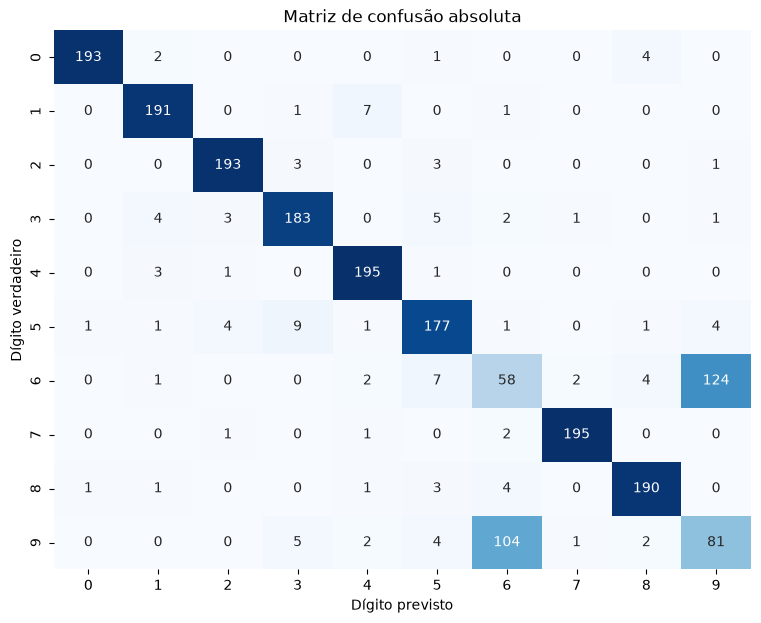

Total de erros: 338
Maior célula fora da diagonal: 124


In [79]:
# Matriz de confusão do melhor modelo sobre as previsões fora da dobra
matriz = confusion_matrix(y, previsoes, labels=classes)

plt.figure(figsize=(9, 7))

sns.heatmap(
    pd.DataFrame(matriz, index=rotulos, columns=rotulos),
    annot=True, fmt="d", cmap="Blues", cbar=False
)

plt.title("Matriz de confusão absoluta")
plt.xlabel("Dígito previsto")
plt.ylabel("Dígito verdadeiro")
plt.show()

total_erros = matriz.sum() - np.trace(matriz)
print("Total de erros:", total_erros)
print("Maior célula fora da diagonal:", matriz[~np.eye(len(classes), dtype=bool)].max())

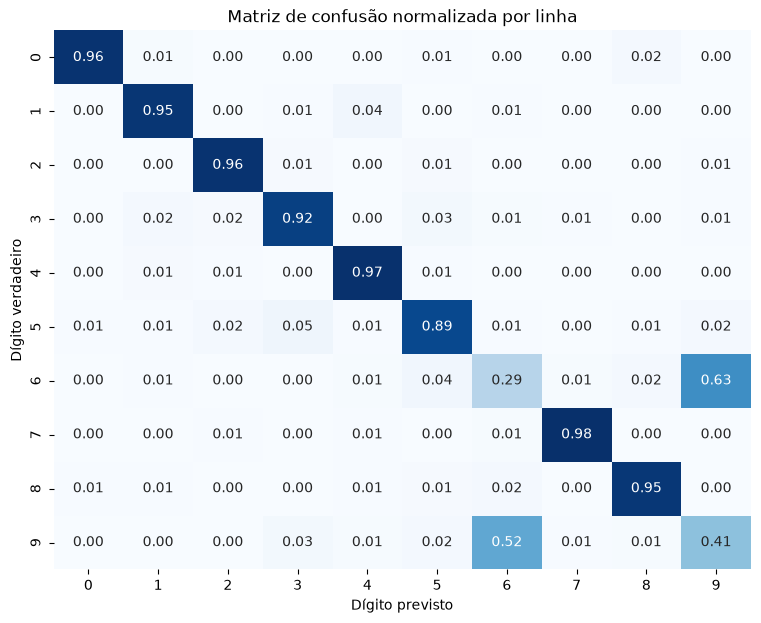

In [80]:
# Normaliza cada linha pelo total de exemplos da classe verdadeira
matriz_normalizada = matriz / matriz.sum(axis=1, keepdims=True)

plt.figure(figsize=(9, 7))

sns.heatmap(
    pd.DataFrame(matriz_normalizada, index=rotulos, columns=rotulos),
    annot=True, fmt=".2f", cmap="Blues", cbar=False
)

plt.title("Matriz de confusão normalizada por linha")
plt.xlabel("Dígito previsto")
plt.ylabel("Dígito verdadeiro")
plt.show()

A matriz desfaz de imediato a hipótese de erro difuso. Das 338 classificações incorretas, duas células concentram a maior parte: 124 dígitos 6 classificados como 9 e 104 dígitos 9 classificados como 6. Nenhuma outra célula fora da diagonal passa de nove instâncias.

A leitura da versão normalizada é ainda mais direta. Oito das dez classes têm entre 0,89 e 0,98 de sua massa sobre a diagonal. As linhas dos dígitos 6 e 9 são a exceção: apenas 0,29 e 0,41 permanecem na classe correta, e o restante migra quase inteiramente para o outro membro do par.

### Desempenho por classe

A matriz mostra onde os erros estão; as métricas por classe quantificam o custo deles. Precisão e revocação respondem a perguntas diferentes: revocação baixa indica que a classe é difícil de recuperar, enquanto precisão baixa indica que o modelo atribui à classe exemplos que não lhe pertencem.

In [81]:
# Calcula precisão, revocação e F1 para cada dígito
relatorio = classification_report(
    y, previsoes,
    labels=classes,
    target_names=rotulos,
    output_dict=True,
    zero_division=0
)

# Organiza o relatório em uma tabela ordenada pela revocação
por_classe = pd.DataFrame(relatorio).T.loc[rotulos, ["precision", "recall", "f1-score", "support"]]
por_classe.columns = ["Precisão", "Revocação", "F1", "Exemplos"]
por_classe.index.name = "Dígito"

por_classe.sort_values("Revocação").round(3)

,Precisão,Revocação,F1,Exemplos
Dígito,,,,
6,0.337,0.293,0.314,198.0
9,0.384,0.407,0.395,199.0
5,0.881,0.889,0.885,199.0
3,0.910,0.920,0.915,199.0
8,0.945,0.950,0.948,200.0
1,0.941,0.955,0.948,200.0
2,0.955,0.965,0.960,200.0
0,0.990,0.965,0.977,200.0
4,0.933,0.975,0.954,200.0


A tabela separa o conjunto em dois regimes. Oito dígitos apresentam F1 entre 0,885 e 0,980, um desempenho alto e homogêneo. Os dígitos 6 e 9 registram F1 de 0,314 e 0,395, muito abaixo do restante.

Para esses dois dígitos, precisão e revocação caem juntas, e isso tem significado próprio. Se apenas a revocação fosse baixa, a classe estaria sendo absorvida por outras; se apenas a precisão fosse baixa, a classe estaria atraindo exemplos alheios. Como as duas caem simultaneamente e de forma simétrica, as duas classes estão trocando exemplos entre si.

### Pares de classes mais confundidos

A célula seguinte soma os dois sentidos de cada confusão para medir o atrito entre cada par de dígitos, e mantém os sentidos separados para avaliar a simetria da troca.

In [82]:
# Soma os dois sentidos de cada confusão e ignora os acertos da diagonal
simetrica = matriz + matriz.T
np.fill_diagonal(simetrica, 0)

pares = []
for i in range(len(classes)):
    for j in range(i + 1, len(classes)):
        if simetrica[i, j] > 0:
            pares.append({
                "Par": "{} e {}".format(rotulos[i], rotulos[j]),
                "Total": simetrica[i, j],
                "{} visto como {}".format(rotulos[i], rotulos[j]): matriz[i, j],
                "{} visto como {}".format(rotulos[j], rotulos[i]): matriz[j, i],
                "% dos erros": 100 * simetrica[i, j] / total_erros
            })

pares = pd.DataFrame(pares).sort_values("Total", ascending=False).reset_index(drop=True)

print("Oito pares mais confundidos:\n")
print(pares.head(8)[["Par", "Total", "% dos erros"]].round(1).to_string(index=False))

print("\nO par líder responde por {:.1f}% dos erros.".format(pares.iloc[0]["% dos erros"]))
print("Os seis primeiros pares concentram {:.1f}% dos erros.".format(pares.head(6)["% dos erros"].sum()))

Oito pares mais confundidos:

  Par  Total  % dos erros
6 e 9    228         67.5
3 e 5     14          4.1
1 e 4     10          3.0
6 e 8      8          2.4
5 e 9      8          2.4
5 e 6      8          2.4
2 e 5      7          2.1
2 e 3      6          1.8

O par líder responde por 67.5% dos erros.
Os seis primeiros pares concentram 81.7% dos erros.


O par formado pelos dígitos 6 e 9 responde sozinho por 67,5% de todos os erros do modelo. O segundo colocado, o par 3 e 5, responde por 4,1%. A diferença entre o primeiro e o segundo é de mais de uma ordem de grandeza.

A troca é também notavelmente simétrica, com volume semelhante nos dois sentidos. Não se trata de uma classe dominando a outra, o que aconteceria se uma delas fosse mais densa ou mais dispersa na região de fronteira. O modelo simplesmente não consegue decidir entre as duas, e distribui os erros quase igualmente nos dois sentidos.

Esse padrão pede uma explicação que não está nos algoritmos, mas na representação dos dados.

### Por que justamente 6 e 9

Os momentos de Zernike são descritores de forma construídos a partir de polinômios ortogonais definidos sobre o disco unitário. Usa-se a magnitude dos momentos, e não sua fase, justamente porque a magnitude é **invariante a rotação**: uma forma girada em qualquer ângulo produz o mesmo vetor de atributos.

Em reconhecimento de formas essa é uma propriedade desejável, pois um objeto permanece o mesmo objeto quando observado de outro ângulo. Aplicada a dígitos manuscritos, ela destrói informação essencial: **um 9 girado em 180 graus é um 6**. Se a representação descarta a orientação, ela descarta exatamente aquilo que distingue os dois dígitos.

A consequência é que o erro não pertence ao classificador. Nenhum algoritmo pode recuperar uma informação que não está presente em sua entrada. A célula seguinte testa essa hipótese de três formas independentes.

In [83]:
from sklearn.neighbors import NearestNeighbors
import itertools

# Padroniza os atributos para que as distâncias sejam comparáveis
X_escalado = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns)

# Primeira evidência: distância entre os centroides de cada par de classes
centroides = X_escalado.groupby(y.values).mean()

distancias = {
    (a, b): np.linalg.norm(centroides.loc[a] - centroides.loc[b])
    for a, b in itertools.combinations(classes, 2)
}
proximos = sorted(distancias.items(), key=lambda item: item[1])

print("Pares de classes mais próximos no espaço padronizado:")
for (a, b), distancia in proximos[:5]:
    print("   dígitos {} e {}: {:.2f}".format(digito[a], digito[b], distancia))
print("   mediana entre todos os 45 pares: {:.2f}".format(np.median(list(distancias.values()))))

Pares de classes mais próximos no espaço padronizado:
   dígitos 6 e 9: 0.26
   dígitos 2 e 5: 3.51
   dígitos 3 e 5: 3.73
   dígitos 2 e 3: 3.90
   dígitos 0 e 8: 3.92
   mediana entre todos os 45 pares: 5.77


In [84]:
# Segunda evidência: um classificador dedicado apenas a separar os dois dígitos
par = [7, 10]
no_par = y.isin(par).values

acuracia_binaria = cross_val_score(
    Pipeline([
        ("padronizacao", StandardScaler()),
        ("modelo", SVC(kernel="rbf", random_state=seed))
    ]),
    X[no_par], y[no_par],
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=seed)
)

print("SVM treinado somente para distinguir 6 de 9:")
print("   acurácia: {:.4f} ± {:.4f}   (acaso = 0.50)".format(acuracia_binaria.mean(), acuracia_binaria.std()))

SVM treinado somente para distinguir 6 de 9:
   acurácia: 0.3172 ± 0.0453   (acaso = 0.50)


In [85]:
# Terceira evidência: a classe do vizinho mais próximo dentro do par
vizinhos = NearestNeighbors(n_neighbors=2).fit(X_escalado[no_par])
_, indices = vizinhos.kneighbors(X_escalado[no_par])
classe_do_vizinho = y[no_par].values[indices[:, 1]]

print("Entre as instâncias de 6 e 9, o vizinho mais próximo:")
print("   pertence ao MESMO dígito em {:.1f}% dos casos".format(100 * (classe_do_vizinho == y[no_par].values).mean()))
print("   pertence ao OUTRO dígito em {:.1f}% dos casos".format(100 * (classe_do_vizinho != y[no_par].values).mean()))

Entre as instâncias de 6 e 9, o vizinho mais próximo:
   pertence ao MESMO dígito em 22.4% dos casos
   pertence ao OUTRO dígito em 77.6% dos casos


As três evidências convergem e são mais fortes do que a hipótese inicial previa.

Os centroides dos dígitos 6 e 9 estão a uma distância de 0,26 no espaço padronizado, contra uma mediana de 5,77 entre os 45 pares possíveis. As duas classes ocupam praticamente a mesma posição: são vinte e duas vezes mais próximas entre si do que o par típico, e o segundo par mais próximo está treze vezes mais distante que elas.

O classificador dedicado, treinado exclusivamente para separar os dois dígitos em um problema binário e balanceado, obtém acurácia de 0,317. O resultado não é apenas ruim, é sistematicamente **pior que o acaso**, e um chute aleatório acertaria mais.

A terceira evidência explica esse comportamento aparentemente absurdo. O vizinho mais próximo de uma instância do par pertence ao dígito oposto em 77,6% dos casos. Cada 6 tem ao seu lado, no espaço de atributos, o 9 que lhe corresponde por rotação. Qualquer método que decida por proximidade é levado sistematicamente à classe errada, e é por isso que o desempenho cai abaixo do acaso em vez de apenas se aproximar dele.

### A confiança atribuída pelo modelo

Um classificador útil não precisa acertar sempre, mas precisa sinalizar quando está inseguro. A confiança é tomada como a maior probabilidade atribuída pelo modelo à instância.

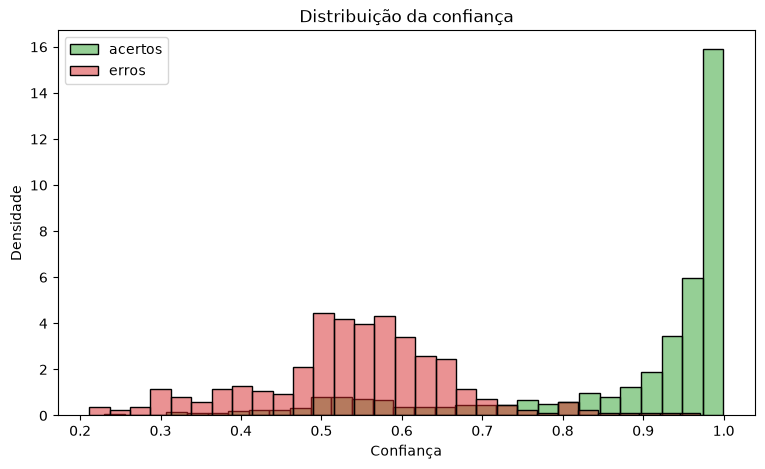

In [86]:
# Compara a distribuição de confiança entre acertos e erros
plt.figure(figsize=(9, 5))

sns.histplot(x=confianca[acertou], bins=30, stat="density", color="tab:green",
             alpha=0.5, label="acertos")
sns.histplot(x=confianca[~acertou], bins=30, stat="density", color="tab:red",
             alpha=0.5, label="erros")

plt.title("Distribuição da confiança")
plt.xlabel("Confiança")
plt.ylabel("Densidade")
plt.legend()
plt.show()

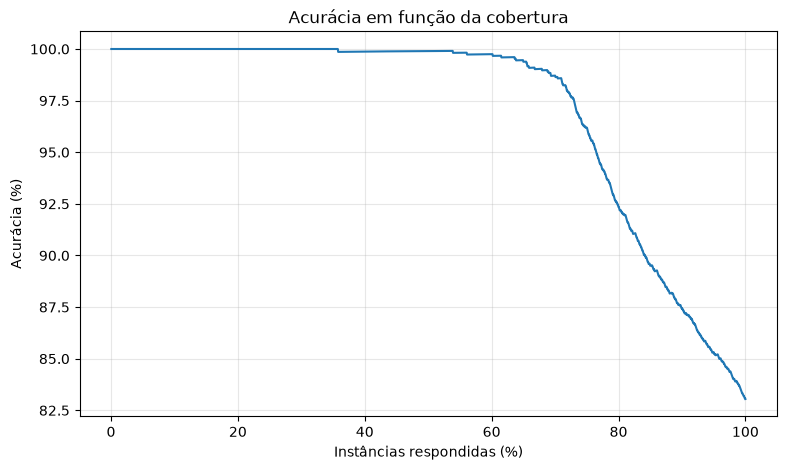

Acurácia se o modelo respondesse apenas os casos mais confiáveis:
   respondendo 100% das instâncias: 0.8305
   respondendo  95% das instâncias: 0.8532
   respondendo  90% das instâncias: 0.8746
   respondendo  80% das instâncias: 0.9235
   respondendo  70% das instâncias: 0.9871


In [87]:
# Ordena as instâncias da maior para a menor confiança
ordem_confianca = np.argsort(-confianca)
acuracia_acumulada = np.cumsum(acertou[ordem_confianca]) / np.arange(1, len(y) + 1)
cobertura = 100 * np.arange(1, len(y) + 1) / len(y)

plt.figure(figsize=(9, 5))

plt.plot(cobertura, 100 * acuracia_acumulada)

plt.title("Acurácia em função da cobertura")
plt.xlabel("Instâncias respondidas (%)")
plt.ylabel("Acurácia (%)")
plt.grid(alpha=0.3)
plt.show()

print("Acurácia se o modelo respondesse apenas os casos mais confiáveis:")
for fracao in [1.0, 0.95, 0.90, 0.80, 0.70]:
    posicao = int(fracao * len(y)) - 1
    print("   respondendo {:3.0f}% das instâncias: {:.4f}".format(100 * fracao, acuracia_acumulada[posicao]))

In [88]:
# Posição da classe correta no ranking de probabilidades
ranking = np.argsort(-probabilidades, axis=1)
posicao_correta = np.array([
    list(classes[ranking[i]]).index(y.values[i]) + 1 for i in range(len(y))
])

print("Entre as {} instâncias classificadas incorretamente:".format((~acertou).sum()))
print("   a classe correta era a segunda mais provável em {:.1f}% dos casos".format(
    100 * (posicao_correta[~acertou] == 2).mean()))
print("   a classe correta estava entre as três mais prováveis em {:.1f}% dos casos".format(
    100 * (posicao_correta[~acertou] <= 3).mean()))

Entre as 338 instâncias classificadas incorretamente:
   a classe correta era a segunda mais provável em 16.6% dos casos
   a classe correta estava entre as três mais prováveis em 91.7% dos casos


As duas distribuições são claramente distintas. Os acertos concentram-se junto ao valor máximo de confiança, enquanto os erros formam uma massa deslocada para a esquerda, próxima de 0,5, que é o valor esperado quando a probabilidade se divide entre duas classes.

A curva de cobertura traduz isso em termos operacionais. Respondendo todas as instâncias, a acurácia é de 0,8305. Abstendo-se dos 20% menos confiáveis, sobe para 0,9235; abstendo-se dos 30%, alcança 0,9871. Um modelo que pudesse recusar os casos duvidosos erraria pouco mais de uma vez em cada cem, o que indica que a informação sobre a própria incerteza está corretamente codificada nas probabilidades.

O ranking reforça essa leitura: em 91,7% dos erros a classe correta ainda figura entre as três mais prováveis. O modelo raramente descarta a resposta certa, apenas não consegue colocá-la em primeiro lugar.

### Os erros no espaço da PCA

A projeção por PCA foi usada na análise exploratória para visualizar a sobreposição entre classes. Aqui ela é recalculada sobre o conjunto sem duplicatas e usada para localizar geometricamente as instâncias classificadas incorretamente.

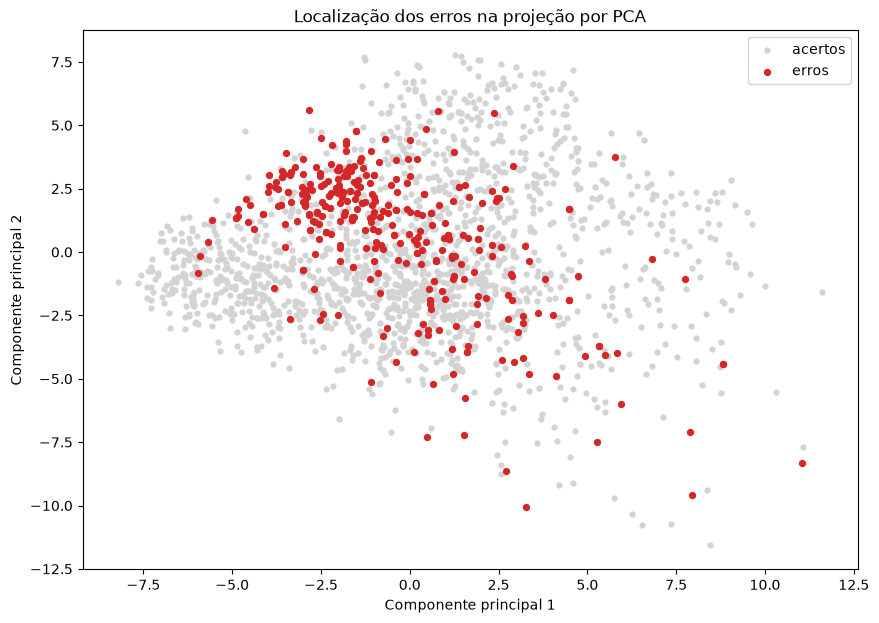

Variabilidade explicada pelas duas componentes: 44.63%


In [89]:
# Recalcula a projeção sobre o conjunto já sem as instâncias duplicadas
pca_erros = PCA(n_components=2, random_state=seed)
componentes_erros = pca_erros.fit_transform(X_escalado)

plt.figure(figsize=(10, 7))

plt.scatter(componentes_erros[acertou, 0], componentes_erros[acertou, 1],
            c="lightgray", s=12, label="acertos")
plt.scatter(componentes_erros[~acertou, 0], componentes_erros[~acertou, 1],
            c="tab:red", s=18, label="erros")

plt.title("Localização dos erros na projeção por PCA")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend()
plt.show()

print("Variabilidade explicada pelas duas componentes: {:.2f}%".format(
    100 * pca_erros.explained_variance_ratio_.sum()))

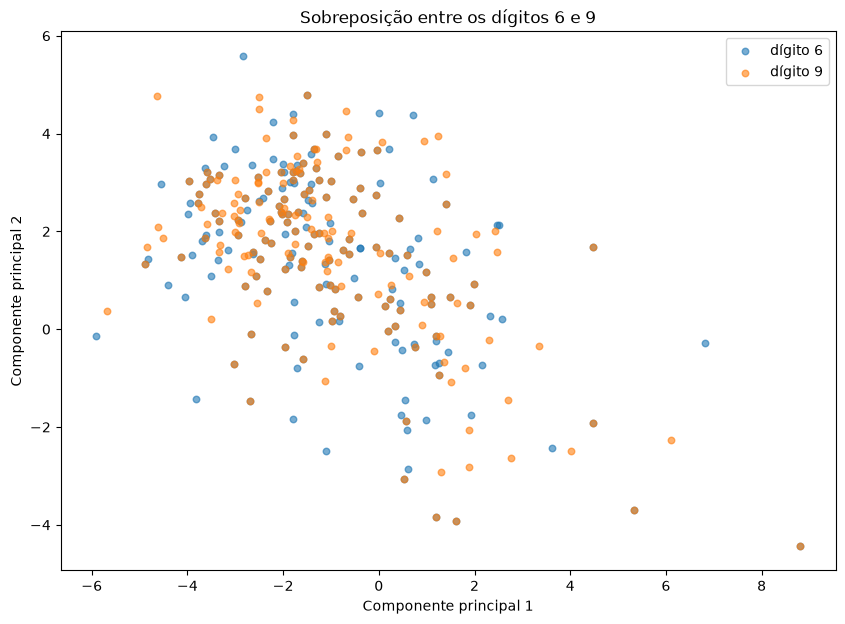

In [90]:
# Destaca somente os dois dígitos do par crítico
cores = {7: "tab:blue", 10: "tab:orange"}

plt.figure(figsize=(10, 7))

for classe in par:
    selecao = (y.values == classe)
    plt.scatter(componentes_erros[selecao, 0], componentes_erros[selecao, 1],
                c=cores[classe], s=22, alpha=0.6, label="dígito {}".format(digito[classe]))

plt.title("Sobreposição entre os dígitos 6 e 9")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend()
plt.show()

O primeiro gráfico mostra que os erros não se espalham pelo conjunto: concentram-se em uma região densa e bem delimitada. O segundo revela que essa região é ocupada pelos dígitos 6 e 9, cujas nuvens de pontos não formam dois grupos vizinhos, mas uma única nuvem em que as duas cores se misturam sem estrutura aparente.

Cabe uma ressalva metodológica. As duas componentes explicam 44,63% da variabilidade total, de modo que a ausência de separação na projeção não prova, por si só, ausência de separação nas 47 dimensões originais. A projeção é aqui uma ilustração, e não a demonstração. A evidência de fato foi estabelecida na seção anterior, com medidas calculadas no espaço completo.

### Todos os modelos erram as mesmas instâncias?

Se a dificuldade estivesse nos algoritmos, cada um erraria de acordo com seu próprio viés indutivo e as falhas se sobreporiam pouco. Se a dificuldade estiver na representação, os quatro modelos devem falhar nas mesmas instâncias.

A comparação exige previsões fora da dobra para todos os modelos, obtidas da mesma forma que para o melhor deles.

In [91]:
# Obtém as previsões fora da dobra de cada um dos quatro modelos
previsoes_modelos = {}

for nome, resultado in resultados.items():
    previsao = np.empty(len(y), dtype=int)

    for (indices_treino, indices_teste), estimador in zip(cv_externa.split(X, y), resultado["estimator"]):
        previsao[indices_teste] = estimador.predict(X.iloc[indices_teste])

    previsoes_modelos[nome] = previsao

# Marca, para cada instância, quais modelos erraram
erros_modelos = pd.DataFrame({nome: previsao != y.values for nome, previsao in previsoes_modelos.items()})
quantos_erram = erros_modelos.sum(axis=1)

print("Distribuição das instâncias pelo número de modelos que erram:\n")
for quantidade, total in quantos_erram.value_counts().sort_index().items():
    print("   {} de 4 modelos: {:4d} instâncias ({:.1f}%)".format(quantidade, total, 100 * total / len(y)))

Distribuição das instâncias pelo número de modelos que erram:

   0 de 4 modelos: 1415 instâncias (71.0%)
   1 de 4 modelos:  133 instâncias (6.7%)
   2 de 4 modelos:  127 instâncias (6.4%)
   3 de 4 modelos:  118 instâncias (5.9%)
   4 de 4 modelos:  201 instâncias (10.1%)


In [92]:
# Compara a sobreposição observada com a esperada sob independência
taxas = erros_modelos.mean()
esperado = len(y) * np.prod(taxas.values)
observado = (quantos_erram == 4).sum()

print("Instâncias erradas pelos quatro modelos:")
print("   observado: {}".format(observado))
print("   esperado se os erros fossem independentes: {:.1f}".format(esperado))
print("   razão: {:.0f} vezes mais que o acaso".format(observado / esperado))

# Composição do núcleo de instâncias que nenhum modelo acerta
nucleo = (quantos_erram == 4).values
composicao = y[nucleo].map(digito).value_counts().sort_index()

print("\nDígitos verdadeiros das {} instâncias do núcleo:".format(nucleo.sum()))
for d, total in composicao.items():
    print("   dígito {}: {:3d}".format(d, total))

print("\nOs dígitos 6 e 9 representam {:.1f}% do núcleo.".format(
    100 * composicao.loc[[6, 9]].sum() / nucleo.sum()))

Instâncias erradas pelos quatro modelos:
   observado: 201
   esperado se os erros fossem independentes: 2.7
   razão: 73 vezes mais que o acaso

Dígitos verdadeiros das 201 instâncias do núcleo:
   dígito 0:   2
   dígito 1:   3
   dígito 2:   2
   dígito 3:   8
   dígito 4:   4
   dígito 5:  13
   dígito 6:  84
   dígito 7:   3
   dígito 8:   3
   dígito 9:  79

Os dígitos 6 e 9 representam 81.1% do núcleo.


A sobreposição é massiva. Há 201 instâncias que os quatro modelos erram simultaneamente, contra as 2,7 que seriam esperadas se as falhas fossem independentes entre si: uma concentração 73 vezes maior que o acaso.

Regressão logística, k-NN, SVM e Random Forest têm vieses indutivos distintos, pois traçam fronteiras lineares, decidem por proximidade, projetam os dados em um espaço de dimensão mais alta e particionam o espaço por cortes axiais, respectivamente. Que quatro estratégias tão diferentes falhem nas mesmas instâncias afasta a hipótese de limitação algorítmica.

A composição do núcleo remove a última dúvida: 163 das 201 instâncias, ou 81,1%, são dígitos 6 e 9. O que nenhum modelo acerta é justamente o que a representação não codifica.

Vale registrar o outro extremo da tabela: 1.415 instâncias, ou 71% do conjunto, são acertadas pelos quatro modelos. O conjunto se divide entre uma maioria que qualquer método resolve e um núcleo que nenhum resolve, com relativamente pouco espaço intermediário onde a escolha do algoritmo faz diferença.

### Características das instâncias difíceis

Resta caracterizar as instâncias problemáticas. Duas perguntas orientam esta última etapa: o modelo chega a errar com convicção, e as instâncias erradas são atípicas dentro de sua própria classe?

In [93]:
# Erros cometidos com alta confiança
erros_confiantes = (~acertou) & (confianca > 0.9)

print("Erros com confiança acima de 0,9: {} ({:.1f}% dos {} erros)".format(
    erros_confiantes.sum(), 100 * erros_confiantes.sum() / total_erros, total_erros))

print("\nConfiança média:")
print("   instâncias dos dígitos 6 e 9: {:.3f}".format(confianca[no_par].mean()))
print("   instâncias dos demais dígitos: {:.3f}".format(confianca[~no_par].mean()))

Erros com confiança acima de 0,9: 3 (0.9% dos 338 erros)

Confiança média:
   instâncias dos dígitos 6 e 9: 0.546
   instâncias dos demais dígitos: 0.892


In [94]:
# Verifica se o modelo identifica ao menos o grupo a que a instância pertence
indice_par = [list(classes).index(classe) for classe in par]
massa_no_par = probabilidades[:, indice_par].sum(axis=1)

print("Comportamento do modelo diante dos dígitos 6 e 9:")
print("   probabilidade média atribuída ao conjunto de dois dígitos: {:.3f}".format(massa_no_par[no_par].mean()))
print("   acerta que a instância pertence ao par: {:.1f}% dos casos".format(
    100 * np.isin(previsoes[no_par], par).mean()))
print("   acerta qual dos dois dígitos é: {:.1f}% dos casos".format(100 * acertou[no_par].mean()))

Comportamento do modelo diante dos dígitos 6 e 9:
   probabilidade média atribuída ao conjunto de dois dígitos: 0.899
   acerta que a instância pertence ao par: 92.4% dos casos
   acerta qual dos dois dígitos é: 35.0% dos casos


In [95]:
# Distância de cada instância ao centroide da classe verdadeira e da prevista
distancia_verdadeira = np.array([
    np.linalg.norm(X_escalado.values[i] - centroides.loc[y.values[i]].values) for i in range(len(y))
])
distancia_prevista = np.array([
    np.linalg.norm(X_escalado.values[i] - centroides.loc[previsoes[i]].values) for i in range(len(y))
])

print("Distância média ao centroide da própria classe:")
print("   acertos: {:.2f}".format(distancia_verdadeira[acertou].mean()))
print("   erros:   {:.2f}".format(distancia_verdadeira[~acertou].mean()))

print("\nEntre os erros, a instância está mais próxima do centroide da classe prevista")
print("   do que do centroide da classe verdadeira em {:.0f}% dos casos.".format(
    100 * (distancia_prevista[~acertou] < distancia_verdadeira[~acertou]).mean()))

print("\nAcurácia restrita aos outros oito dígitos: {:.4f}".format(acertou[~no_par].mean()))
print("Acurácia sobre o conjunto completo: {:.4f}".format(acertou.mean()))

Distância média ao centroide da própria classe:
   acertos: 5.07
   erros:   5.38

Entre os erros, a instância está mais próxima do centroide da classe prevista
   do que do centroide da classe verdadeira em 66% dos casos.

Acurácia restrita aos outros oito dígitos: 0.9499
Acurácia sobre o conjunto completo: 0.8305


O primeiro resultado é o mais revelador: apenas três das 338 classificações incorretas foram feitas com confiança superior a 0,9, e nenhuma delas envolve o par 6 e 9. O modelo praticamente nunca erra com convicção. A confiança média cai de 0,892 nos demais dígitos para 0,546 nas instâncias do par crítico, valor muito próximo do 0,5 que caracteriza uma escolha entre duas alternativas equivalentes.

O par de números seguinte descreve com precisão o que o modelo consegue e o que não consegue fazer. Diante de um 6 ou de um 9, ele atribui em média 0,899 de probabilidade ao conjunto formado pelos dois dígitos e acerta em 92,4% dos casos que a instância pertence a esse conjunto. Ao escolher qual dos dois, acerta apenas 35,0%. O modelo identifica corretamente a forma e falha apenas na orientação, que é exatamente a informação eliminada pela invariância dos momentos de Zernike.

As instâncias erradas também não são outliers. A distância média ao centroide da própria classe é de 5,38 nos erros contra 5,07 nos acertos, uma diferença pequena. Em 66% dos erros a instância está de fato mais próxima do centroide da classe prevista do que da verdadeira, ou seja, a decisão do modelo é razoável do ponto de vista geométrico. O erro não vem de instâncias deformadas ou ruidosas, mas de instâncias que ocupam legitimamente a posição de outra classe.

Por fim, a medida do impacto: restrita aos outros oito dígitos, a acurácia do modelo é de 0,9499, contra 0,8305 no conjunto completo.

## **Conclusões**

Quais são suas conclusões sobre os experimentos realizados? Resuma o que foi alcançado no trabalho e tente propor estratégias para trabalhos futuros com esses dados. Agradeço também se puderem dar um feedback sobre o que acharam do trabalho. E declarem explicitamente o uso de ferramentas de LLM para auxílio ao desenvolvimento do trabalho.

### O que foi realizado

O trabalho aplicou um pipeline completo de Aprendizado de Máquina ao conjunto mfeat-zernike, composto por 2.000 instâncias descritas por 47 momentos de Zernike e distribuídas uniformemente entre dez dígitos manuscritos.

A verificação inicial não encontrou valores ausentes nem inconsistências de tipo, e os seis pares de instâncias duplicadas foram removidos, reduzindo o conjunto a 1.994 exemplos. A padronização mostrou-se necessária diante das escalas muito distintas entre os atributos, enquanto a redução de dimensionalidade foi avaliada e descartada, por exigir 22 das 47 componentes para preservar 99% da variabilidade.

A avaliação seguiu validação cruzada aninhada, com dez dobras externas estratificadas e três dobras internas para o ajuste de hiperparâmetros. A padronização foi encapsulada no mesmo `Pipeline` do classificador, garantindo que a média e o desvio padrão fossem estimados apenas sobre os dados de treinamento de cada dobra e eliminando o vazamento de informação para a partição de teste.

Quatro técnicas foram comparadas sob condições idênticas, tendo um `DummyClassifier` como referência.

### Conclusões sobre os experimentos

**Os atributos carregam informação discriminativa substancial.** Os quatro modelos superaram com larga margem o baseline de 0,100 de acurácia. O melhor deles, o SVM com kernel RBF, alcançou 0,831 ± 0,025 de acurácia e 0,826 ± 0,026 de F1 macro, contra 0,018 de F1 macro do classificador de referência.

**A vantagem do SVM é estatisticamente significativa, mas modesta.** O teste de Wilcoxon pareado sobre as dez dobras externas indicou superioridade do SVM sobre a regressão logística (p = 0,027), o k-NN (p = 0,025) e a Random Forest (p = 0,002). A diferença para o segundo colocado, contudo, é de apenas 1,05 ponto percentual de acurácia. A Random Forest foi o modelo mais estável entre as dobras, com desvio de 0,011, mas também o de pior desempenho médio, o que sugere que os cortes axiais em que ela se baseia se ajustam mal a atributos contínuos e pouco correlacionados como os momentos de Zernike.

**A escolha do algoritmo importa menos do que a análise inicial sugeria.** A diferença de 5,9 pontos percentuais entre o melhor e o pior modelo é pequena diante do fato de que 71% das instâncias são classificadas corretamente pelos quatro e 10,1% são erradas pelos quatro. Restam cerca de 19% do conjunto em que a escolha do modelo efetivamente altera o resultado.

**O desempenho agregado esconde um comportamento fortemente heterogêneo.** A acurácia de 0,831 não descreve bem o modelo. Sobre oito dos dez dígitos, o SVM alcança 0,950; sobre os dígitos 6 e 9, o F1 cai para 0,314 e 0,395. A média aritmética entre um classificador quase resolvido e um par praticamente aleatório produz um número que não corresponde ao comportamento observado em nenhuma das duas situações.

**A discrepância entre AUC e acurácia é informativa.** O SVM obteve AUC de 0,989 com acurácia de 0,831. Um valor tão alto de AUC indica que o ordenamento das probabilidades é quase sempre correto, ainda que a classe mais provável não seja. Isso é coerente com a análise de erros: em 91,7% das classificações incorretas a classe verdadeira permanecia entre as três mais prováveis.

**A principal conclusão do trabalho diz respeito à representação, e não aos classificadores.** A análise de erros mostrou que 67,5% das falhas se concentram em um único par de dígitos, o 6 e o 9. Os momentos de Zernike são invariantes a rotação por construção, e um 9 girado em 180 graus é um 6, de modo que a representação descarta exatamente a informação que distingue os dois. Quatro evidências independentes sustentam essa leitura, da proximidade entre os centroides à falha simultânea dos quatro modelos sobre as mesmas instâncias. Nenhum ajuste de algoritmo ou de hiperparâmetro alcançaria a limitação, pois ela é anterior ao aprendizado.

**O modelo reconhece a própria incerteza.** Apenas três das 338 classificações incorretas ocorreram com confiança superior a 0,9, e nenhuma delas envolve o par crítico. Diante de um 6 ou de um 9, identifica o grupo corretamente em 92,4% dos casos e erra apenas a escolha interna: reconhece a forma e falha na orientação.

### Limitações

**As comparações múltiplas não foram corrigidas.** O teste de Wilcoxon foi aplicado três vezes sobre o mesmo conjunto de dados. Sob correção de Bonferroni, o limiar passaria de 0,05 para 0,0167 e apenas a comparação com a Random Forest permaneceria significativa. Além disso, as dobras de uma validação cruzada não são independentes entre si, pois seus conjuntos de treinamento se sobrepõem, o que tende a tornar os p-valores otimistas.

**O poder estatístico é limitado pelo número de dobras.** Com dez dobras, o menor p-valor alcançável pelo teste de Wilcoxon bilateral é de aproximadamente 0,002, valor obtido na comparação com a Random Forest. A conclusão dessa comparação está, portanto, no limite do que o procedimento consegue detectar.

### Estratégias para trabalhos futuros

**Adotar classificação com opção de rejeição.** A curva de acurácia em função da cobertura mostrou que o modelo atingiria 0,9871 de acurácia respondendo apenas os 70% de instâncias mais confiáveis. Em uma aplicação real de leitura de dígitos, encaminhar os casos duvidosos para verificação humana seria preferível a responder com uma confiança de 0,5. A análise de custo dessa estratégia é um desdobramento natural.

**Avaliar e calibrar as probabilidades.** Diagramas de confiabilidade e métricas como o erro de calibração esperado permitiriam verificar se a confiança do modelo corresponde à sua taxa de acerto, o que é pré-requisito para qualquer estratégia baseada em limiar de confiança.


### Considerações do grupo sobre o trabalho

O resultado mais surpreendente foi o classificador binário dedicado a separar 6 de 9 obter desempenho abaixo do acaso. O grupo inicialmente suspeitou de um erro de implementação e só aceitou o resultado depois de verificar que um classificador aleatório atingia 0,50 no mesmo problema e que o vizinho mais próximo de cada instância pertencia ao dígito oposto em 77,6% dos casos. A explicação acabou sendo mais interessante que a suspeita inicial.

### Declaração de uso de ferramentas de LLM

O grupo declara o uso de ferramentas de modelos de linguagem no desenvolvimento deste trabalho, nos seguintes termos.

**Ferramenta utilizada.** Claude (Anthropic), por meio da interface Claude Code integrada ao editor.

**Em que foi utilizada:**

Pré-processamento e pipeline de AM. A ferramenta foi usada como assistente na escrita das células de código. Contudo, a referência principal foram os notebooks disponibilizados em aula. Auxiliou também na redação dos textos.

Análise de erros e conclusões. Auxiliou na implementação das células de código da seção de análise de erros, como o cálculo da porcentagem de vizinhos mais próximos dos números duvidosos, e na redação dos textos interpretativos.

## **Referências**

DUIN, R. P. W. *Multiple Features* [conjunto de dados]. UCI Machine Learning Repository, 1998. DOI: 10.24432/C5HC70. Disponível em: <https://archive.ics.uci.edu/dataset/72/multiple>.

WILLEMS, Karlijn. *Python Exploratory Data Analysis Tutorial*. DataCamp, 15 mar. 2017. Disponível em: <https://www.datacamp.com/tutorial/exploratory-data-analysis-python>.

MATERIAL DA DISCIPLINA CMC-15. *Notebook de apoio para análise exploratória de dados*. Google Colab. Disponível em: <https://colab.research.google.com/drive/1jLrzNUQhx9-nOOCv0YNIyaAARQK7TtMp?usp=classroom_web#scrollTo=ehBjoRV42qXa>.